In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [35]:
df = pd.read_csv('../dataset/student_placement_career_success_dataset.csv', usecols=[
'cgpa',
'backlog_history',
'DSA_problems_solved',
'GitHub_repos',
'development_projects_count',
'AI_ML_projects',
'internships_completed',
'hackathons_participated',
'self_learning_hours',
'resume_score'
])


In [36]:
df['GitHub_repos']=df['GitHub_repos'].fillna(df['GitHub_repos'].mean())

In [37]:
X = df.drop("resume_score", axis=1)
y = df["resume_score"]

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
results = {}

In [27]:
def evalute_model(name,y_pred):
    r2value = r2_score(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test,y_pred)

    results[name]={
        'r2_score':r2value,
        'mse':mse,
        'rmse':rmse,
        'mae':mae
    }

In [28]:
from sklearn.linear_model import LinearRegression
linear_reg = LinearRegression()
linear_reg.fit(X_train,y_train)
l_pred=linear_reg.predict(X_test)
evalute_model('Linear Regression',l_pred)

In [29]:
from sklearn.tree import DecisionTreeRegressor
d_tree = DecisionTreeRegressor(max_depth=5,random_state=42)
d_tree.fit(X_train,y_train)
d_pred = d_tree.predict(X_test)
evalute_model('Decision Tree',d_pred)

In [30]:
from sklearn.ensemble import RandomForestRegressor
r_forest = RandomForestRegressor(criterion='squared_error', random_state=42,max_depth= 5, min_samples_leaf= 3,min_samples_split= 2, n_estimators= 200)
r_forest.fit(X_train,y_train)
rf_pred = r_forest.predict(X_test)
evalute_model('Random Forest',rf_pred)

In [31]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
evalute_model('XGBoost', xgb_preds)

In [32]:
model_score = pd.DataFrame(results)
print(model_score)

          Linear Regression  Decision Tree  Random Forest   XGBoost
r2_score       1.000000e+00       0.790498       0.843020  0.993567
mse            6.303062e-26      30.252128      22.667932  0.928891
rmse           2.510590e-13       5.500193       4.761085  0.963790
mae            2.018793e-13       4.347803       3.738042  0.734538


In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": r_forest.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

                      Feature  Importance
4  development_projects_count    0.640990
6       internships_completed    0.185466
2         DSA_problems_solved    0.088692
1             backlog_history    0.083824
8         self_learning_hours    0.000722
5              AI_ML_projects    0.000168
3                GitHub_repos    0.000108
0                        cgpa    0.000028
7     hackathons_participated    0.000002


In [60]:
import joblib
joblib.dump(r_forest, '../model/engineering_score_model.pkl')

['../model/engineering_score_model.pkl']

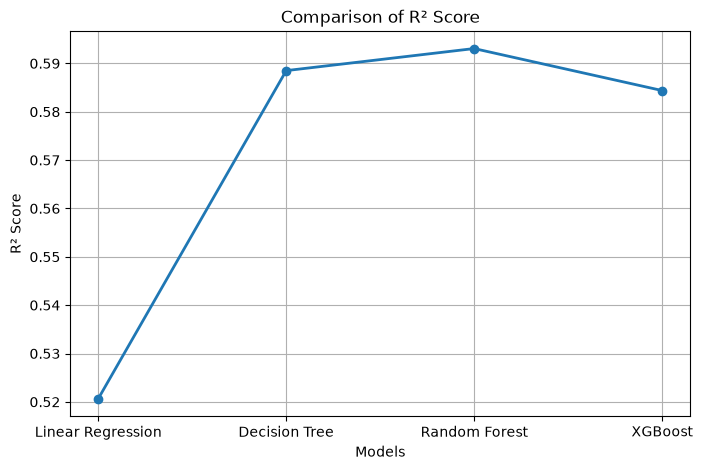

In [6]:
import matplotlib.pyplot as plt

models = ["Linear Regression","Decision Tree","Random Forest","XGBoost"]
r2 = [0.520684,0.588506,0.593068,0.584391]

plt.figure(figsize=(8,5))
plt.plot(models, r2, marker='o', linewidth=2)

plt.title("Comparison of R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.grid(True)

plt.show()

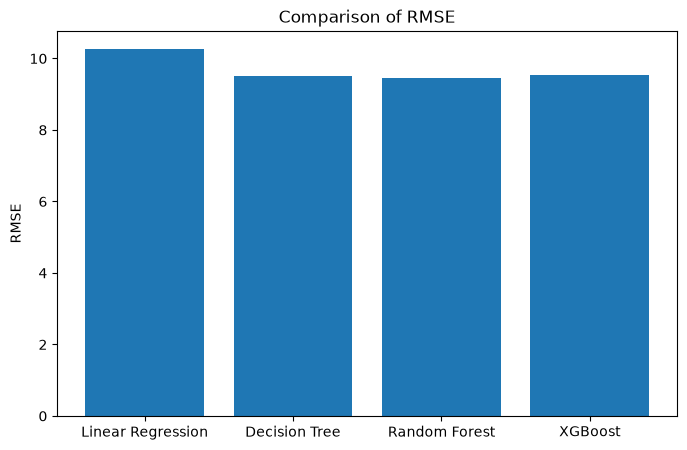

In [7]:
plt.figure(figsize=(8,5))

rmse = [10.256709,9.503401,9.450568,9.550790]

plt.bar(models, rmse)

plt.title("Comparison of RMSE")
plt.ylabel("RMSE")

plt.show()

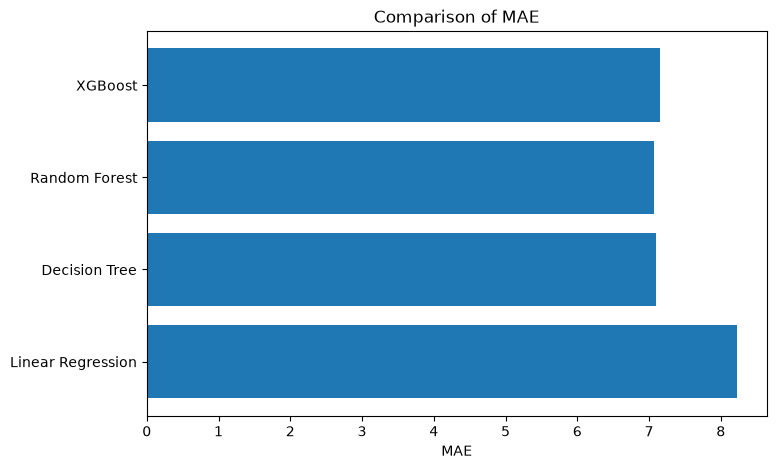

In [8]:
plt.figure(figsize=(8,5))

mae = [8.228967,7.097382,7.068374,7.149823]

plt.barh(models, mae)

plt.title("Comparison of MAE")
plt.xlabel("MAE")

plt.show()